# Feature Evaluation: NASDAQ-100 Microstructure

Every candidate feature this case study has built is measured here one at a time,
against the forward midprice return declared at `setup.yaml::labels.primary`, and
each is recorded with a decision and the evidence behind it. One at a time is the
limit of the exercise: it says which candidates carry information about the label on
their own, not which set of them a model should be trained on.

**Book reference**: §7.3 (univariate feature-label evaluation) and §7.4 (search
accounting and multiple testing). §8.6 is the secondary reference for search control.

**Learning Objectives**:
- Drop from an intraday panel every bar whose forward return would only be known
  inside the later window this case study keeps back for its final test, so that no
  diagnostic on this page reads a period that has been reserved
- Measure how strongly each candidate feature ranks the assets the way the forward
  return ends up ranking them, and how much of that measurement is left once the
  number of candidates tested at once is accounted for
- Decide whether a feature is missing too often, or repeats the previous bar's value
  too often, to be worth testing at all
- Read whether the forward return climbs steadily from the low-ranked assets to the
  high-ranked ones, and find the pairs of features that carry the same evidence twice
- Record a PROCEED, REVISE or STOP decision for every candidate, with the evidence
  that produced it, in a file a later notebook can audit

**What it reads**:
- `features/financial.parquet`, `features/model_based.parquet` (the candidate set)
- `labels/<primary>.parquet` plus the declared forward-return variants, for the
  horizon profile
- `config/setup.yaml` (holdout boundary, label horizons, fold count)

**What it writes**:
- `evaluation/triage_ledger.parquet` - one row per feature with triage decision
- `evaluation/ic_timeseries.parquet` - long-format IC time series, plotted below by
  the IC-through-time figure

**Cross-References**:
- **Upstream**: [`03_financial_features`](03_financial_features.ipynb),
  [`04_model_based_features`](04_model_based_features.ipynb),
  [`02_labels`](02_labels.ipynb)
- **Downstream**: `20_strategy_synthesis/02_feature_evaluation.py`, which reads the
  triage ledger of every case study and tabulates them together. It is the only
  reader of either artifact, and no notebook narrows its feature set by these
  decisions, so a STOP recorded here is a judgment about a feature rather than a
  filter applied on the reader's behalf.

In [1]:
"""Feature Evaluation - NASDAQ-100 Microstructure

Univariate screening of the financial and model-based feature sets against the
declared forward return labels. Produces per-feature triage decisions.
"""

import re
from datetime import datetime

import numpy as np
import plotly.graph_objects as go
import polars as pl
import yaml
from IPython.display import display
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, compute_ic_uncertainty
from plotly.subplots import make_subplots
from scipy.stats import spearmanr
from scipy.stats import t as student_t

from case_studies.utils.feature_engineering import quantile_profile
from utils.cv_splits import generate_cv_splits
from utils.data_quality import validate_modeling_inputs
from utils.paths import get_case_study_dir
from utils.style import COLORS, GRAY_FILLS


def _normalize_symbol_column(df: pl.DataFrame) -> pl.DataFrame:
    if "symbol" in df.columns:
        return df
    msg = f"Expected symbol-like column in frame, found columns={df.columns}"
    raise KeyError(msg)

One parameter is exposed for readers who want a faster pass over the panel.
`MAX_SYMBOLS` keeps only that many of the most frequently quoted names; zero, the
production value, keeps the whole universe. Every cross-sectional statistic below
is computed across the names present at a timestamp, so reducing the universe
narrows every cross-section and the numbers move with it.

In [2]:
MAX_SYMBOLS = 0

In [3]:
CASE_STUDY_ID = "nasdaq100_microstructure"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_WRITE_DIR = EVAL_DIR.resolve(strict=False) if EVAL_DIR.is_symlink() else EVAL_DIR
EVAL_WRITE_DIR.mkdir(parents=True, exist_ok=True)

JOIN_COLS = ["timestamp", "symbol"]
DATE_COL = "timestamp"

## Configuration

The first group of constants describes the case study and is read from
`config/setup.yaml`: which forward return is the primary label, how far ahead it
looks, where the reserved test period begins, and how many walk-forward folds the
pipeline uses. Reading them rather than typing them means a change to the declared
setup moves this notebook with it.

The second group is the screen's own, and is set out after it.

In [4]:
def horizon_minutes(spec: str) -> int:
    """Minutes in a `setup.yaml` label buffer such as `15min`."""
    match = re.fullmatch(r"(\d+)min", str(spec).strip())
    if match is None:
        msg = f"Label buffer {spec!r} is not expressed in minutes"
        raise ValueError(msg)
    return int(match.group(1))


with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)
cv_config = setup["evaluation"]

# The panel is a one-minute grid, so a buffer in minutes is a horizon in bars.
PRIMARY_LABEL = setup["labels"]["primary"]
LABEL_HORIZON = horizon_minutes(setup["labels"]["buffer"])
# The continuous forward-return labels this case study ships, primary first. The
# classification variant is excluded: a rank IC against a binary label answers a
# different question and does not belong on the horizon profile.
LABEL_HORIZONS = {
    name: horizon_minutes(spec)
    for name, spec in [
        (PRIMARY_LABEL, setup["labels"]["buffer"]),
        *sorted(setup["labels"]["variant_buffers"].items()),
    ]
    if name.startswith("fwd_ret")
}
HOLDOUT_START = datetime.fromisoformat(str(cv_config["holdout_start"]))
N_FOLDS = int(cv_config["n_splits"])

# One IC observation per label horizon: at a 15-bar horizon on a one-minute grid,
# consecutive cross-sectional ICs would otherwise overlap in 14 of their 15 bars.
IC_SAMPLE_STEP = LABEL_HORIZON
# Newey-West bandwidth covering one full NYSE regular session of IC observations
# (the calendar is declared at `setup.yaml::evaluation.calendar`). It is derived
# from the sampling step rather than typed so the two cannot drift apart.
SESSION_MINUTES = 390
HAC_MAXLAGS = SESSION_MINUTES // IC_SAMPLE_STEP

### What the screen's own settings decide

None of these is read from the case-study configuration. They are judgments about
what is worth carrying into a model, and a reader working on their own data should
expect to move them.

`COVERAGE_MIN` is the share of bars a feature has to carry a value on. Below it, too
many names drop out of too many cross-sections, and the rank correlation starts to
describe which names happened to have a value rather than the universe.

`STALENESS_MAX` is the share of bars a feature may repeat its previous value on.
A feature repeating on more than half of them is not ranking anything most of the
time.

`FDR_ALPHA` does double duty: it is the share of rejected features allowed to be
false discoveries under the adjustment, and it is the level at which an individual
p-value is called significant before it.

`SIGN_CONSISTENCY_MIN` is the share of folds that have to agree on a direction.
With the fold count declared above, that share can only be zero, one half or one,
so any bar between one half and one means the same thing: both folds, or neither.

`MONOTONICITY_MIN` is what "the quantile profile climbs steadily" means once it is
written down, measured as the rank correlation between quintile index and the mean
return in that quintile.

`REDUNDANCY_CUT` is how alike two features have to rank the universe before they are
treated as one piece of evidence rather than two.

`IC_THRESHOLD` is the effect-size bar for the exploration arm of the triage rule at
the end. A fifteen-minute cross-section of a hundred names is wide and noisy, and a
mean IC of a few thousandths is the scale a usable signal has here; the bar is set
at that scale as a judgment, not derived from a test. How many candidates clear it
is reported with the triage counts rather than assumed.

`MIN_PERIODS_DEFAULT` is the thinnest cross-section worth a rank correlation. The
universe declared at `setup.yaml::universe` runs to about a hundred names, so ten is
a low bar that bites only on the sparsest timestamps, and it falls to the universe
size when `MAX_SYMBOLS` reduces the panel.

In [5]:
COVERAGE_MIN = 0.70
STALENESS_MAX = 0.50
FDR_ALPHA = 0.05
SIGN_CONSISTENCY_MIN = 0.60
MONOTONICITY_MIN = 0.80
REDUNDANCY_CUT = 0.70
IC_THRESHOLD = 0.003
MIN_PERIODS_DEFAULT = 10

## 0. The Panel, and Holding the Test Period Back

Load the financial features, the model-based features and the primary label, and
join them on `(timestamp, symbol)`.

**What is held back.** `setup.yaml::evaluation.holdout_start` marks the beginning of
a period this case study reserves for one final test, several notebooks later.
Everything on this page is computed on the period before it, and the rule that draws
the line is about *when a label is known* rather than when a feature is observed: a
bar's forward return is only settled `LABEL_HORIZON` minutes after the bar, so a bar
keeps its place in the panel only when that settlement time falls strictly before the
boundary. The last `LABEL_HORIZON` minutes before the boundary go with it, since
their returns are measured over price moves inside the reserved period.

The filter is pushed into the lazy scans, so the reserved rows are never
materialized at all and no statistic below - not the coverage screen, not the
quantile profile, not the redundancy correlation - can reach one.

The walk-forward folds come first, because everything else is restricted to the
windows they define. `generate_cv_splits` reads the fold count and window lengths
from `setup.yaml` and derives the boundaries from the label frame's own timestamps;
`04_model_based_features` derives its folds from the same call with the same
arguments, so a fold id denotes the same window on both sides of the join below.

In [6]:
features_path = CASE_DIR / "features" / "financial.parquet"
temporal_path = CASE_DIR / "features" / "model_based.parquet"
label_path = CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet"

splits = generate_cv_splits(
    pl.scan_parquet(label_path).select(DATE_COL).unique().sort(DATE_COL).collect(),
    case_study_id=CASE_STUDY_ID,
    label_buffer=setup["labels"]["buffer"],
)

financial_cols = [
    c for c in pl.read_parquet_schema(features_path) if c not in ("timestamp", "symbol")
]
temporal_cols = [
    c for c in pl.read_parquet_schema(temporal_path) if c not in ("timestamp", "symbol", "fold")
]
all_feature_cols = financial_cols + temporal_cols

The three scans are filtered before anything is collected: first to the reduced
universe if the reader asked for one, then to the bars whose forward return settles
before the reserved period begins.

In [7]:
symbol_filter = None
if MAX_SYMBOLS > 0:
    counts = pl.scan_parquet(features_path).group_by("symbol").len().collect()
    top_syms = counts.sort("len", descending=True).head(MAX_SYMBOLS)["symbol"].to_list()
    symbol_filter = pl.col("symbol").is_in(top_syms)

features = pl.scan_parquet(features_path)
temporal = pl.scan_parquet(temporal_path)
label_df = pl.scan_parquet(label_path)

if symbol_filter is not None:
    features = features.filter(symbol_filter)
    temporal = temporal.filter(symbol_filter)
    label_df = label_df.filter(symbol_filter)

label_endpoint = pl.col(DATE_COL) + pl.duration(minutes=LABEL_HORIZON)
before_holdout = label_endpoint < HOLDOUT_START
features = _normalize_symbol_column(features.filter(before_holdout).collect())
temporal = _normalize_symbol_column(temporal.filter(before_holdout).collect())
label_df = _normalize_symbol_column(label_df.filter(before_holdout).collect())

**Resolving the fold dimension.** `model_based.parquet` carries one value per
`(timestamp, symbol, fold)`, because each fold refits the estimators that produce
it, while the panel this notebook screens needs exactly one value per bar and
symbol. A refitted value is out of sample only inside the validation window of the
fold that produced it, so each fold contributes the rows inside its own validation
window and nothing else. The retraining fold `04_model_based_features` appends for
the final test is not among the folds `generate_cv_splits` returns, so it is left
behind by the same filter.

The windows do not overlap, so this selects exactly one value per bar and symbol.
The assertion is what establishes that rather than assuming it: had two windows
overlapped, a feature would take two values on one bar and every cross-section
below would double-count it.

In [8]:
val_windows = {int(s["fold"]): (s["val_start"], s["val_end"]) for s in splits}
_ts_dtype = temporal.schema[DATE_COL]
temporal = (
    temporal.filter(pl.col("fold").is_in(list(val_windows)))
    .filter(
        pl.col("fold")
        .replace_strict({f: s for f, (s, _) in val_windows.items()}, default=None)
        .cast(_ts_dtype)
        <= pl.col(DATE_COL)
    )
    .filter(
        pl.col(DATE_COL)
        <= pl.col("fold")
        .replace_strict({f: e for f, (_, e) in val_windows.items()}, default=None)
        .cast(_ts_dtype)
    )
    .drop("fold")
)
assert temporal.select(JOIN_COLS).is_duplicated().sum() == 0, (
    "validation windows overlap; a refitted feature would take two values on one bar"
)

label_col = [c for c in label_df.columns if c not in ("timestamp", "symbol")][0]

The three frames join on `(timestamp, symbol)` into the panel every diagnostic below
runs on, and the two assertions establish the properties the rest of the notebook
assumes: that no row's label reaches the reserved period, and that no bar and symbol
appears twice. Both are checked on the assembled panel rather than inferred from the
filters, because a duplicated key does not raise anywhere - it quietly gives one
decision time twice the weight in every cross-section.

In [9]:
eval_panel = features.join(temporal, on=JOIN_COLS, how="left")
eval_panel = eval_panel.join(label_df, on=JOIN_COLS, how="inner")
del features, temporal, label_df

assert eval_panel.select(label_endpoint.max()).item() < HOLDOUT_START
assert eval_panel.select(pl.struct(JOIN_COLS).n_unique()).item() == len(eval_panel)

**Every candidate is screened on the bars where it can exist.** The features from
`04_model_based_features` are refitted per fold and carry a value only inside a
validation window, while the features from `03_financial_features` are defined on
every bar. Measured over the whole period before the reserved one, the first group
would look as though it were missing wherever no window reaches, and the coverage
screen below would read a property of the design as a broken feature. Narrowing the
panel to the union of the validation windows puts both groups on the same bars,
which is also what makes their two rank correlations comparable.

In [10]:
IN_VALIDATION = pl.any_horizontal(
    [
        (pl.col(DATE_COL) >= pl.lit(start).cast(_ts_dtype))
        & (pl.col(DATE_COL) <= pl.lit(end).cast(_ts_dtype))
        for start, end in val_windows.values()
    ]
)
n_before_windows = len(eval_panel)
eval_panel = eval_panel.filter(IN_VALIDATION)
print(
    f"Narrowed to the union of the validation windows: {n_before_windows:,} -> "
    f"{len(eval_panel):,} rows"
)

n_rows = len(eval_panel)
n_symbols = eval_panel["symbol"].n_unique()
n_dates = eval_panel[DATE_COL].n_unique()
MIN_PERIODS = min(MIN_PERIODS_DEFAULT, n_symbols)
print(f"Panel: {n_rows:,} rows, {n_symbols} symbols, {n_dates:,} timestamps")
print(
    f"Spanning {eval_panel[DATE_COL].min()} to {eval_panel[DATE_COL].max()},"
    f" with every label settled before {HOLDOUT_START.date()}"
)
print(
    f"Features: {len(financial_cols)} financial + {len(temporal_cols)} model-based"
    f" = {len(all_feature_cols)} total"
)
print(f"Label: {label_col}")

Narrowed to the union of the validation windows: 11,983,269 -> 8,024,510 rows
Panel: 8,024,510 rows, 111 symbols, 79,082 timestamps
Spanning 2020-06-30 10:31:00 to 2021-06-30 15:44:00, with every label settled before 2021-07-01
Features: 66 financial + 22 model-based = 88 total
Label: fwd_ret_15m


### What is in the candidate set

Eighty-odd columns is a count, and a count is not something a reader can judge a
screen against. The candidate set is organised into **families**, where a family is
a group of columns testing the same hypothesis about the market.

The features built from prices and quotes carry their families in
`setup.yaml::features.families`, one row per family holding a pattern that claims its
columns, the role the family plays, how far back it looks and how many bars it is
published late. Reading the grouping from that declaration rather than retyping a
lookup table keeps one definition of what a family is, and it is what puts a feature
together with its cross-sectional z-score twin: the declaration says each family is
represented at both scales, so `rel_spread_15m` and `rel_spread_15m_xs` are one
hypothesis measured two ways rather than two hypotheses.

The model-based features have no rows in that declaration, because they are grouped
by the estimator that produced them rather than by a market quantity. They are
assigned from their column names, and they are assigned first: several of them are
built on realized volatility and carry names a price-and-quote pattern would
otherwise claim, which would file a spectral estimator under the volatility family it
was estimated from.

The declared patterns are globs over column names, where `*` stands for any suffix.
That is how one pattern claims both a level column and the cross-sectional z-score
column named after it.

In [11]:
DECLARED_FAMILIES = [
    (family["name"], re.compile("^(?:" + family["pattern"].replace("*", ".*") + ")$"))
    for family in setup["features"]["families"]
]
DECLARED_ROLE = {family["name"]: family["role"] for family in setup["features"]["families"]}
DECLARED_LAG = {family["name"]: family["lag"] for family in setup["features"]["families"]}


def declared_family(feat: str) -> str | None:
    """The `setup.yaml` family whose pattern claims this column, if any."""
    base = feat[: -len("_xs")] if feat.endswith("_xs") else feat
    for name, pattern in DECLARED_FAMILIES:
        if pattern.match(feat) or pattern.match(base):
            return name
    return None


def model_based_family(feat: str) -> str:
    """Estimator family, from the column names `04_model_based_features` writes."""
    lowered = feat.lower()
    if "har" in lowered:
        return "temporal_har"
    if any(k in lowered for k in ("spectral", "fft", "freq", "period", "entropy")):
        return "temporal_fft"
    if "sig" in lowered:
        return "temporal_signature"
    return "temporal_other"


families = {}
for feat in all_feature_cols:
    if feat in temporal_cols:
        families[feat] = model_based_family(feat)
    else:
        families[feat] = declared_family(feat) or "other"

unclaimed = sorted(f for f, fam in families.items() if fam == "other")
if unclaimed:
    print(f"Features matched by no declared family: {unclaimed}")

The table below is the candidate set as the domain groups it: how many columns each
family contributes, how many of those are a cross-sectional z-score rather than a
level, what the family is there to do, and how many bars late it is published. The
publication lag is the one column to read before anything else on this page: a
family lagged by a bar is one whose value at a bar was not readable until the next
one, which is what keeps the correlations below from being a measurement of the
future. It is blank for the model-based groups, which have no row in the declaration
to read a lag from.

In [12]:
family_rows = [
    {
        "family": fam,
        "columns": sum(1 for f, g in families.items() if g == fam),
        "of which z-scores": sum(1 for f, g in families.items() if g == fam and f.endswith("_xs")),
        "role": DECLARED_ROLE.get(fam, "model output"),
        "published late (bars)": DECLARED_LAG.get(fam),
    }
    for fam in sorted(set(families.values()))
]
display(pl.DataFrame(family_rows).sort("columns", descending=True))

family,columns,of which z-scores,role,published late (bars)
str,i64,i64,str,i64
"""order_flow""",22,11,"""signal""",1
"""quote_liquidity""",12,6,"""state""",0
"""temporal_signature""",12,0,"""model output""",null
"""volatility""",12,6,"""state""",0
"""price_impact""",8,4,"""state""",1
"""temporal_fft""",8,0,"""model output""",null
"""microprice""",6,3,"""signal""",0
"""session_clock""",4,0,"""state""",0
"""hidden_liquidity""",2,1,"""state""",1


## Artifact Quality Gate

Before any feature is judged on what it predicts, the panel is checked for the
defects that make a prediction meaningless whatever the correlation says:
infinities, values so large they can only be a construction error, columns that
turn out to hold no value at all, and forward returns outside what the instrument
can move in the horizon. The bound on the label is a doubling in fifteen minutes,
which no NASDAQ-100 constituent reaches without the exchange halting it first.

This runs on the assembled panel, so it sees the model-based columns as well as the
financial ones, and it runs on exactly the rows the screens below use. A critical
finding raises rather than printing, because a defect here is a defect in an
upstream artifact and is not this notebook's to work around.

It is a different question from the per-feature coverage and staleness screens that
follow: this asks whether the numbers are numbers, those ask whether a feature is
present and moving often enough to rank anything.

In [13]:
_ = validate_modeling_inputs(
    features_df=eval_panel,
    label_df=eval_panel,
    feature_cols=all_feature_cols,
    label_col=label_col,
    join_cols=JOIN_COLS,
    asset_col="symbol",
    max_abs_return=1.0,
    fail_on_critical=True,
)

Data Quality Gate: 0 CRITICAL, 1 WARNING
  [!] WARNING: 1 features have values |x| > 1e+06: dollar_vol(2324863)


## 1. Correctness Screens

Two questions per feature, both about whether it is in a state to rank anything.
**Coverage** is the fraction of bars carrying a value: a feature absent from a third
of the panel contributes cross-sections built from whichever names happened to have
it. **Staleness** is the fraction of bars repeating the previous bar's value, which
on intraday data is the signature of a quote that stopped updating while the book
moved on.

Book §7.3 asks four correctness questions of a candidate feature set. These are two
of them. The other two - whether each feature is timestamped and lagged to
information that was available when the bar closed, and whether it is masked to the
same eligible rows as the label - are answered where the features are built, against
the publication lag shown in the table above.

**Gate**: a feature clears when its coverage reaches `COVERAGE_MIN` and its
staleness stays at or below `STALENESS_MAX`. Read a high staleness value carefully.
The screen counts repeats and cannot ask why a value repeated, so a flag that is true
for the first half hour of every session, and an index naming which frequency
dominated a spectrum, both register as stale for the same reason a frozen quote does.
Anything above the bound leaves the candidate set either way, which means the screen
also removes features that were built to repeat.

In [14]:
coverage = {}
for feat in all_feature_cols:
    n_valid = eval_panel[feat].drop_nulls().len()
    coverage[feat] = n_valid / n_rows if n_rows > 0 else 0.0

# One comparison per symbol is lost to the shift, hence the adjusted denominator.
sorted_panel = eval_panel.sort(JOIN_COLS)
stale_exprs = [
    (pl.col(f) == pl.col(f).shift(1).over("symbol")).alias(f"_stale_{f}") for f in all_feature_cols
]
stale_df = sorted_panel.select(stale_exprs)
staleness = {
    f: float(stale_df[f"_stale_{f}"].sum()) / max(n_rows - n_symbols, 1) for f in all_feature_cols
}
del stale_df, sorted_panel

The gate records which of the two checks a feature failed, not merely that it
failed, so the reason reaches the ledger written at the end.

In [15]:
correctness = {}
failure_reason = {}
for feat in all_feature_cols:
    cov_ok = coverage[feat] >= COVERAGE_MIN
    stale_ok = staleness[feat] <= STALENESS_MAX
    correctness[feat] = cov_ok and stale_ok
    if not cov_ok:
        failure_reason[feat] = "coverage_below_minimum"
    elif not stale_ok:
        failure_reason[feat] = "repeats_too_often"

n_pass = sum(correctness.values())
n_fail = len(correctness) - n_pass
print(f"Gate: coverage >= {COVERAGE_MIN:.0%}, staleness <= {STALENESS_MAX:.0%}")
print(f"Correctness gate: {n_pass} PASS, {n_fail} FAIL")

if n_fail > 0:
    display(
        pl.DataFrame(
            {
                "feature": list(failure_reason),
                "coverage": [coverage[f] for f in failure_reason],
                "staleness": [staleness[f] for f in failure_reason],
                "reason": list(failure_reason.values()),
            }
        )
    )

Gate: coverage >= 70%, staleness <= 50%
Correctness gate: 83 PASS, 5 FAIL


feature,coverage,staleness,reason
str,f64,f64,str
"""cross_locked_share""",1.0,0.719133,"""repeats_too_often"""
"""is_first_30m""",1.0,1.0,"""repeats_too_often"""
"""is_last_30m""",1.0,0.993615,"""repeats_too_often"""
"""vol_dominant_period""",0.999933,0.836825,"""repeats_too_often"""
"""rv_dominant_period""",0.999836,0.834315,"""repeats_too_often"""


## 2. Univariate Association

The **information coefficient**, or IC, is the rank correlation between a feature
and the forward return taken *across the assets quoted at one timestamp*: it asks
whether the names the feature ranks highest are the names that go on to return the
most, and it says nothing about whether the market as a whole went up. One such
correlation is computed at each sampled timestamp, giving a series, and the series
is then averaged.

The average of a series is not worth much without a standard error, and the usual
one assumes each observation carries fresh information. Consecutive intraday ICs do
not: neighbouring cross-sections predict overlapping stretches of the same forward
returns. Newey-West standard errors relax that assumption by letting an observation
be correlated with the `HAC_MAXLAGS` observations before it, which here is one
trading session of them. The series is sorted on time before it reaches the
estimator, because a lag structure computed over an arbitrary row order describes
nothing.

**Sampling.** The panel is on a one-minute grid while the label looks fifteen
minutes ahead, so cross-sections one minute apart share fourteen of the fifteen
minutes they are predicting and their ICs are near-copies of each other. Keeping one
timestamp per label horizon leaves observations that barely overlap. This is the one
place in the pipeline where the IC is not computed at every decision time, and the
overlap is the reason.

**What that sampling does not do.** `gather_every` strides the sorted list of unique
timestamps, and the stride does not restart at each session open, so a retained
timestamp sits at a different point in one session than in the next. The
observations stay spread evenly through the day; they are not aligned to it.

In [16]:
evaluable_features = [f for f in all_feature_cols if correctness[f]]

all_timestamps = eval_panel[DATE_COL].unique().sort()
sample_ts = all_timestamps.gather_every(IC_SAMPLE_STEP)
eval_sampled = eval_panel.join(sample_ts.to_frame(), on=DATE_COL, how="semi")
print(
    f"Evaluating {len(evaluable_features)} features on {len(sample_ts):,}"
    f" sampled timestamps ({len(eval_sampled):,} rows)"
)

Evaluating 83 features on 5,273 sampled timestamps (535,055 rows)


Some candidates take the same value across every name at a timestamp: how far into
the session the bar sits is a property of the clock, not of the asset. They can
still condition a model, but a correlation taken across a set of identical values
is undefined, so they are identified here and left out of the ranking rather than
entered into it with a missing result.

In [17]:
cs_std_df = eval_sampled.group_by(DATE_COL).agg(
    [pl.col(f).std().alias(f) for f in evaluable_features]
)
date_level_features = set()
for feat in evaluable_features:
    mean_std = cs_std_df[feat].drop_nulls().mean()
    if mean_std is not None and mean_std < 1e-10:
        date_level_features.add(feat)

if date_level_features:
    print(f"Identical across the cross-section, so not ranked: {sorted(date_level_features)}")

Identical across the cross-section, so not ranked: ['time_since_open', 'time_to_close']


All of the correlations are computed in one pass: grouping the sampled panel by
timestamp and asking for one rank correlation per feature within each group gives
the whole feature-by-timestamp table at once. Timestamps quoting fewer than
`MIN_PERIODS` names are dropped first, since a rank correlation over a handful of
assets is mostly noise.

In [18]:
cs_features = [f for f in evaluable_features if f not in date_level_features]

ts_counts = eval_sampled.group_by(DATE_COL).len().filter(pl.col("len") >= MIN_PERIODS)
eval_sub = eval_sampled.join(ts_counts.select(DATE_COL), on=DATE_COL, how="semi")

ic_wide = (
    eval_sub.group_by(DATE_COL)
    .agg(
        [pl.corr(f, label_col, method="spearman").alias(f) for f in cs_features]
        + [pl.len().alias("n_obs")]
    )
    .sort(DATE_COL)
)

print(f"IC computed: {len(cs_features)} features across {len(ic_wide):,} timestamps")

IC computed: 81 features across 5,273 timestamps


The wide table is split into one series per feature, and each series goes to the
Newey-West estimator.

A cross-section in which a feature happens to hold one value for every name has no
rank correlation, and Polars reports that as `NaN` rather than as a missing value.
`NaN` is not an observation of the IC and it propagates: left in, it turns every
mean, rolling window and interval computed from the series into `NaN` too.
Filtering on `is_finite` removes both that and any genuine null in one step. A
feature left with fewer than twenty usable observations is not ranked at all.

In [19]:
ic_results = {}
ic_timeseries = {}
for feat in cs_features:
    ic_df = ic_wide.select([DATE_COL, pl.col(feat).alias("ic"), "n_obs"]).filter(
        pl.col("ic").is_finite()
    )
    if len(ic_df) < 20:
        continue
    hac_stats = compute_ic_hac_stats(ic_df, ic_col="ic", maxlags=HAC_MAXLAGS)
    ic_results[feat] = hac_stats
    ic_timeseries[feat] = ic_df

print(f"Newey-West statistics for {len(ic_results)} features ranked across the cross-section")
print(f"Not ranked, identical across the cross-section: {len(date_level_features)}")

Newey-West statistics for 81 features ranked across the cross-section
Not ranked, identical across the cross-section: 2


### The IC Series Itself

The mean IC is a one-number summary of a series, and two of the patterns that decide
whether a feature is usable are visible only in the series itself: an association
carried entirely by one episode, and an association that changes sign partway
through. The left panel draws the per-timestamp IC of the leading feature with a
rolling mean over it.

The right panel puts three ways of bounding the mean on one axis, for the leading
features. The **naive** interval assumes every observation is independent. The
**Newey-West** interval allows each to be correlated with the session of
observations before it. The **block-bootstrap** bounds resample contiguous stretches
of the series and assume neither a variance formula nor a shape for the
distribution. Where the three disagree, the naive one is the optimistic one.

The series drawn here is the one written to `evaluation/ic_timeseries.parquet` at
the end of the notebook: the figure is its first reader, and the file is the same
values for anyone who wants them at a different grain.

In [20]:
# One trading week of IC observations, at one observation per label horizon.
IC_ROLLING_WINDOW = 5 * SESSION_MINUTES // IC_SAMPLE_STEP
BOOT_BOUNDS = ("ci_boot_lower", "ci_boot_upper")

leaders = sorted(ic_results, key=lambda name: abs(ic_results[name]["mean_ic"]), reverse=True)[:8]
# `compute_ic_uncertainty` sets its lag to `horizon - 1` and its bootstrap block to
# `horizon`, both counted in observations of the series it is handed, so passing one
# more than `HAC_MAXLAGS` gives the bands the same bandwidth as the table above.
ic_uncertainty = {
    feature: compute_ic_uncertainty(ic_timeseries[feature], horizon=HAC_MAXLAGS + 1, ic_col="ic")
    for feature in leaders
}
leader = leaders[0] if leaders else None
print(f"Leading feature by absolute mean IC: {leader}")

Leading feature by absolute mean IC: r1m


In [21]:
def interval_arms(features: list[str], lower: str, upper: str) -> dict:
    """Asymmetric Plotly error bars from a pair of interval bounds."""
    return {
        "type": "data",
        "symmetric": False,
        "array": [
            ic_uncertainty[name][upper] - ic_uncertainty[name]["mean_ic"] for name in features
        ],
        "arrayminus": [
            ic_uncertainty[name]["mean_ic"] - ic_uncertainty[name][lower] for name in features
        ],
    }

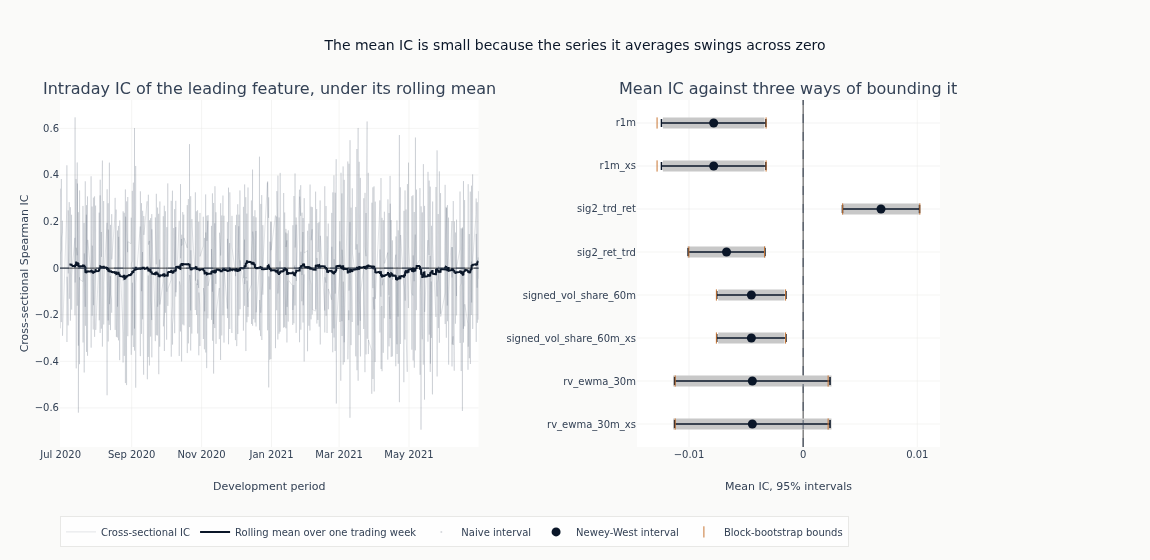

In [22]:
if leader:
    leader_series = ic_timeseries[leader].with_columns(
        pl.col("ic").rolling_mean(IC_ROLLING_WINDOW).alias("rolling")
    )
    interval_features = list(reversed(leaders))
    interval_means = [ic_uncertainty[name]["mean_ic"] for name in interval_features]
    fig = make_subplots(
        rows=1,
        cols=2,
        column_widths=[0.58, 0.42],
        subplot_titles=(
            "Intraday IC of the leading feature, under its rolling mean",
            "Mean IC against three ways of bounding it",
        ),
        horizontal_spacing=0.18,
    )
    _ = fig.add_trace(
        go.Scatter(
            x=leader_series[DATE_COL],
            y=leader_series["ic"],
            mode="lines",
            line={"color": COLORS["neutral"], "width": 0.4},
            opacity=0.35,
            name="Cross-sectional IC",
        ),
        row=1,
        col=1,
    )
    _ = fig.add_trace(
        go.Scatter(
            x=leader_series[DATE_COL],
            y=leader_series["rolling"],
            mode="lines",
            line={"color": COLORS["blue"], "width": 2},
            name="Rolling mean over one trading week",
        ),
        row=1,
        col=1,
    )
    _ = fig.add_hline(
        y=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"}, row=1, col=1
    )
    _ = fig.add_trace(
        go.Scatter(
            x=interval_means,
            y=interval_features,
            mode="markers",
            marker={"color": COLORS["neutral"], "size": 1, "opacity": 0.0},
            error_x=interval_arms(interval_features, "ci_naive_lower", "ci_naive_upper")
            | {"color": GRAY_FILLS["tertiary"], "thickness": 11, "width": 0},
            name="Naive interval",
        ),
        row=1,
        col=2,
    )
    _ = fig.add_trace(
        go.Scatter(
            x=interval_means,
            y=interval_features,
            mode="markers",
            marker={"color": COLORS["blue"], "size": 9},
            error_x=interval_arms(interval_features, "ci_hac_lower", "ci_hac_upper")
            | {"color": COLORS["blue"], "thickness": 1.5},
            name="Newey-West interval",
        ),
        row=1,
        col=2,
    )
    _ = fig.add_trace(
        go.Scatter(
            x=[ic_uncertainty[name][bound] for name in interval_features for bound in BOOT_BOUNDS],
            y=[name for name in interval_features for _ in BOOT_BOUNDS],
            mode="markers",
            marker={"color": COLORS["copper"], "size": 8, "symbol": "line-ns-open"},
            name="Block-bootstrap bounds",
        ),
        row=1,
        col=2,
    )
    _ = fig.add_vline(
        x=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"}, row=1, col=2
    )
    fig.update_layout(
        title="The mean IC is small because the series it averages swings across zero",
        height=560,
        width=1150,
        margin={"l": 60, "r": 210},
        legend={"orientation": "h", "y": -0.2},
    )
    fig.update_yaxes(title_text="Cross-sectional Spearman IC", row=1, col=1)
    fig.update_xaxes(title_text="Development period", row=1, col=1)
    fig.update_xaxes(title_text="Mean IC, 95% intervals", row=1, col=2)
    fig.show()

### Fold-Level Stability

An average taken over the whole period hides whether the association was there
throughout or only in one stretch of it. Splitting the IC series by walk-forward
fold and taking the mean within each shows which. A feature whose fold means point
in opposite directions is unreliable however large its t-statistic over the pooled
series.

With the `N_FOLDS` folds declared at `setup.yaml::evaluation.n_splits`, the share of
folds agreeing on a direction takes only the values zero, one half and one, and an
interquartile range across two numbers is not a quantity worth reporting. The figure
shows the fold means themselves instead, with the median and the lower of the two
marked.

**How the agreement is scored, and what that rules out.** The score counts folds
with a *positive* IC rather than folds sharing the feature's own direction. A
feature whose folds agree on a negative sign therefore scores zero and cannot clear
the stability arm of the promotion rule, however stable it is. On a screen where
many of the largest associations are negative, that is a real restriction on what
this arm can promote, and it is listed among the limitations at the end.

Each fold is scored over the window its features were refitted out of sample on, so
the agreement is measured on the same folds the panel was resolved with.

In [23]:
fold_boundaries = [
    (
        pl.lit(split["val_start"]).cast(_ts_dtype),
        pl.lit(split["val_end"]).cast(_ts_dtype),
    )
    for split in splits
]

fold_stats = {}
for feat in ic_results:
    fold_ics = []
    ts = ic_timeseries[feat]
    for fold_start, fold_end in fold_boundaries:
        fold_ic = ts.filter((pl.col(DATE_COL) >= fold_start) & (pl.col(DATE_COL) <= fold_end))
        if len(fold_ic) >= 5:
            fold_ics.append(float(fold_ic["ic"].mean()))

    if fold_ics:
        # Measured against the feature's own direction rather than against "positive".
        # The promotion route this feeds tests the absolute average agreement, so it
        # accepts a feature that ranks names inversely; counting only positive folds
        # would score that feature zero however reliably it held its direction, and it
        # could never reach the route. The weakest fold follows the same rule - it is
        # the fold furthest against the feature's own direction, which for an inverse
        # feature is its algebraic maximum.
        direction = 1.0 if (ic_results[feat]["mean_ic"] or 0.0) >= 0 else -1.0
        signed = [ic * direction for ic in fold_ics]
        fold_stats[feat] = {
            "n_folds": len(fold_ics),
            "sign_consistency": sum(1 for s in signed if s > 0) / len(fold_ics),
            "worst_fold_ic": fold_ics[int(np.argmin(signed))],
            "best_fold_ic": fold_ics[int(np.argmax(signed))],
            "median_fold_ic": float(np.median(fold_ics)),
            "fold_ics": fold_ics,
        }

n_consistent = sum(1 for s in fold_stats.values() if s["sign_consistency"] >= SIGN_CONSISTENCY_MIN)
print(
    f"Fold stability: {n_consistent}/{len(fold_stats)} features holding one direction in"
    f" >= {SIGN_CONSISTENCY_MIN:.0%} of folds"
)

Fold stability: 36/81 features holding one direction in >= 60% of folds


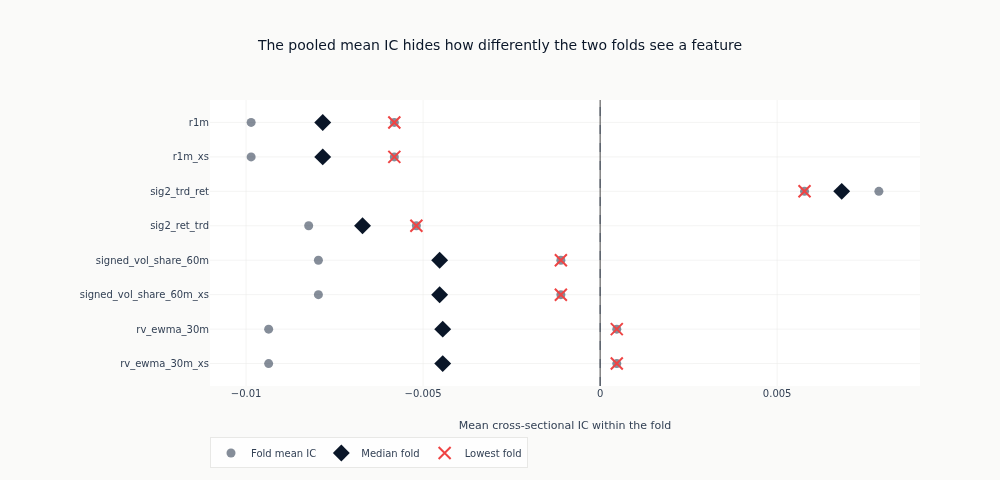

In [24]:
stability_features = [name for name in reversed(leaders) if name in fold_stats]
if stability_features:
    fig = go.Figure()
    _ = fig.add_trace(
        go.Scatter(
            x=[value for name in stability_features for value in fold_stats[name]["fold_ics"]],
            y=[name for name in stability_features for _ in fold_stats[name]["fold_ics"]],
            mode="markers",
            marker={"color": COLORS["neutral"], "size": 9, "opacity": 0.6},
            name="Fold mean IC",
        )
    )
    _ = fig.add_trace(
        go.Scatter(
            x=[fold_stats[name]["median_fold_ic"] for name in stability_features],
            y=stability_features,
            mode="markers",
            marker={"color": COLORS["blue"], "size": 13, "symbol": "diamond"},
            name="Median fold",
        )
    )
    _ = fig.add_trace(
        go.Scatter(
            x=[fold_stats[name]["worst_fold_ic"] for name in stability_features],
            y=stability_features,
            mode="markers",
            marker={
                "color": COLORS["negative"],
                "size": 12,
                "symbol": "x-thin",
                "line": {"width": 2, "color": COLORS["negative"]},
            },
            name="Lowest fold",
        )
    )
    _ = fig.add_vline(x=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"})
    fig.update_layout(
        title="The pooled mean IC hides how differently the two folds see a feature",
        xaxis_title="Mean cross-sectional IC within the fold",
        height=480,
        width=1000,
        margin={"l": 210},
        legend={"orientation": "h", "y": -0.18},
    )
    fig.show()

## 3. Search Accounting and Multiple Testing

**The searched set.** A p-value is interpretable only against the set of tests it
came out of, so the set is declared before the adjustment is applied. It is the
union of the financial features `03_financial_features` generates from the window
register at `setup.yaml::features.windows`, in both the level and cross-sectional
z-score representation each family declares, and the model-based features
`04_model_based_features` generates from its estimator families. Generation is
blind to the label: no feature in the set was chosen after seeing an IC, and the
set is the same one whatever this notebook finds. Only the primary label is
screened here; the other declared horizons enter as the sensitivity check below,
not as separate tests.

**The adjustment.** Benjamini-Hochberg at `FDR_ALPHA`, applied over every feature
with a computable cross-sectional IC. Testing each candidate at the same nominal
level lets the expected number of false positives grow in proportion to how many
candidates there are: at `FDR_ALPHA` and this many features, several would be called
significant even if none of them carried anything. Benjamini-Hochberg instead
controls the expected share of false discoveries among the features it does reject.
That expected count under the unadjusted rule is printed beside the three counts
below, which is what makes the size of the adjustment legible.

In [25]:
feature_names = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in feature_names]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=FDR_ALPHA, return_details=True)

eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["temporal" if f in temporal_cols else "financial" for f in feature_names],
        "ic_mean": [ic_results[f]["mean_ic"] for f in feature_names],
        "hac_se": [ic_results[f]["hac_se"] for f in feature_names],
        "hac_t": [ic_results[f]["t_stat"] for f in feature_names],
        "hac_p": p_values,
        "fdr_p": list(fdr_result["adjusted_p_values"]),
        "fdr_sig": list(fdr_result["rejected"]),
        "naive_t": [ic_results[f]["naive_t_stat"] for f in feature_names],
    },
    schema_overrides={
        "ic_mean": pl.Float64,
        "hac_se": pl.Float64,
        "hac_t": pl.Float64,
        "hac_p": pl.Float64,
        "fdr_p": pl.Float64,
        "fdr_sig": pl.Boolean,
        "naive_t": pl.Float64,
    },
).sort(pl.col("ic_mean").cast(pl.Float64, strict=False).abs(), descending=True)

Three counts of "significant" follow, and they have to be three different
quantities. `compute_ic_hac_stats` returns the Newey-West p-value alongside the
unadjusted t-statistic, so the unadjusted p-value is recomputed here from that
t-statistic; reading the returned p-value as though it were the unadjusted one would
compare a quantity with itself.

In [26]:
naive_p_values = [
    float(2 * student_t.sf(abs(ic_results[f]["naive_t_stat"]), df=ic_results[f]["n_periods"] - 1))
    for f in feature_names
]
n_searched = len(feature_names)
expected_false_positives = FDR_ALPHA * n_searched

n_significant_naive = sum(1 for p in naive_p_values if p < FDR_ALPHA)
n_significant_hac = sum(1 for p in p_values if p < FDR_ALPHA)
n_significant_fdr = int(fdr_result["n_rejected"])


def per_surviving_feature(unadjusted_count: int, adjusted_count: int) -> str:
    """Unadjusted rejections per rejection the adjusted rule keeps.

    Undefined when the adjusted rule rejects nothing: substituting one for a zero
    denominator reports a finite ratio where none exists, and the reader cannot
    tell the substitution from a measurement.
    """
    if adjusted_count == 0:
        return "undefined (the adjusted rule rejected nothing)"
    return f"{unadjusted_count / adjusted_count:.2f} per surviving feature"


strongest = eval_summary.row(0, named=True) if len(eval_summary) else None

In [27]:
print(
    f"Of {len(all_feature_cols)} candidate features, {n_pass} cleared the correctness screen"
    f" and {n_searched} produced a cross-sectional IC against {label_col}."
)
print(
    f"The unadjusted rule would be expected to call {expected_false_positives:.1f} of them"
    f" significant with nothing there at all."
)
print(f"  Called significant, unadjusted: {n_significant_naive}")
print(f"  Called significant, Newey-West: {n_significant_hac}")
print(f"  Called significant, BH-FDR:     {n_significant_fdr}")
print(
    "  Unadjusted rejections against Newey-West: "
    f"{per_surviving_feature(n_significant_naive, n_significant_hac)}"
)
print(
    "  Unadjusted rejections against BH-FDR:     "
    f"{per_surviving_feature(n_significant_naive, n_significant_fdr)}"
)
if strongest is not None:
    print(
        f"Largest association in the set: {strongest['feature']} at a mean IC of"
        f" {strongest['ic_mean']:+.4f} (Newey-West t {strongest['hac_t']:+.2f},"
        f" unadjusted t {strongest['naive_t']:+.2f})."
    )

Of 88 candidate features, 83 cleared the correctness screen and 81 produced a cross-sectional IC against fwd_ret_15m.
The unadjusted rule would be expected to call 4.0 of them significant with nothing there at all.
  Called significant, unadjusted: 11
  Called significant, Newey-West: 11
  Called significant, BH-FDR:     6
  Unadjusted rejections against Newey-West: 1.00 per surviving feature
  Unadjusted rejections against BH-FDR:     1.83 per surviving feature
Largest association in the set: r1m at a mean IC of -0.0078 (Newey-West t -3.36, unadjusted t -3.45).


### Ranking, with the Inference Adjustment Visible

The left panel ranks the leading features by absolute mean IC and colours each bar
by whether it cleared the false-discovery adjustment, so individual significance and
the set-wide decision stay separable. The right panel plots the Newey-West
t-statistic against its unadjusted twin for every feature in the searched set: a
point pulled toward zero off the diagonal is a feature whose apparent significance
came from correlation between neighbouring observations of its IC series rather than
from the size of the association.

How close the points sit to the diagonal is the thing to read. Sampling at the label
horizon has already removed most of the overlap the Newey-West correction exists to
undo, so it has little left to do here and the two counts printed above are close;
what thins the candidate set is the false-discovery adjustment, not the lag
correction.

Bars run horizontally. At this many feature names a rotated vertical axis is not
legible.

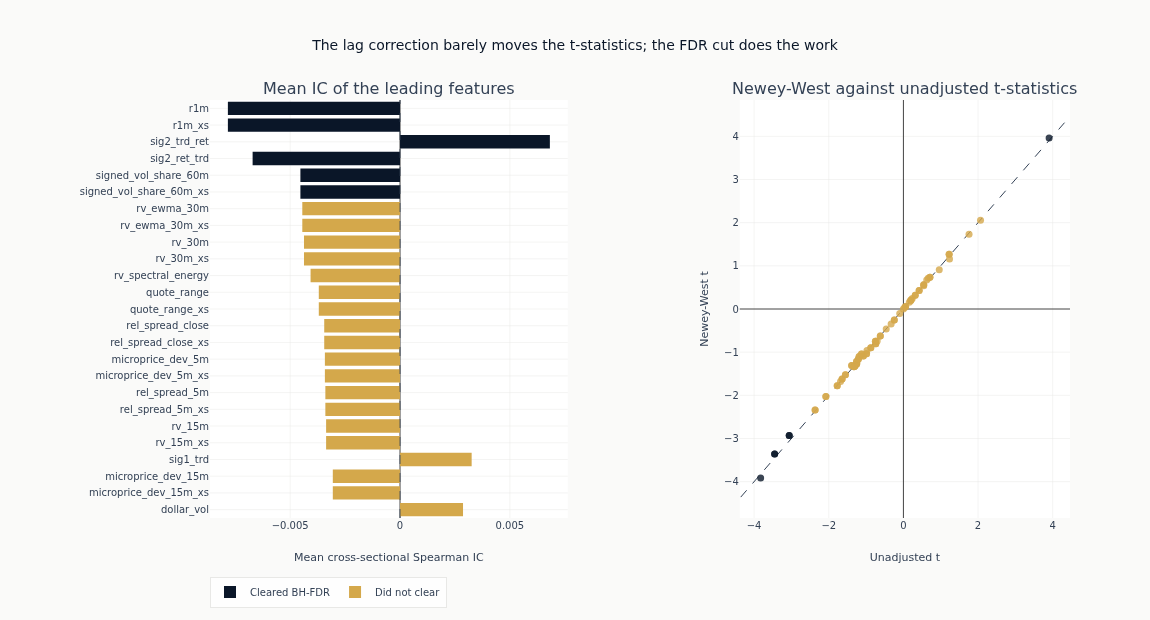

In [28]:
RANKED_FEATURES = 25
top = eval_summary.head(min(RANKED_FEATURES, len(eval_summary))).reverse()

fig = make_subplots(
    rows=1,
    cols=2,
    column_widths=[0.52, 0.48],
    subplot_titles=[
        "Mean IC of the leading features",
        "Newey-West against unadjusted t-statistics",
    ],
    horizontal_spacing=0.2,
)
for cleared, color, name in (
    (True, COLORS["blue"], "Cleared BH-FDR"),
    (False, COLORS["amber"], "Did not clear"),
):
    arm = top.filter(pl.col("fdr_sig").fill_null(False) == cleared)
    if not len(arm):
        continue
    _ = fig.add_trace(
        go.Bar(
            x=arm["ic_mean"].to_list(),
            y=arm["feature"].to_list(),
            orientation="h",
            marker_color=color,
            name=name,
            legendgroup=name,
        ),
        row=1,
        col=1,
    )
_ = fig.add_vline(
    x=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"}, row=1, col=1
)

max_t = (
    max(
        float(eval_summary["naive_t"].abs().max() or 1.0),
        float(eval_summary["hac_t"].abs().max() or 1.0),
    )
    * 1.1
)
_ = fig.add_trace(
    go.Scatter(
        x=[-max_t, max_t],
        y=[-max_t, max_t],
        mode="lines",
        line={"dash": "dash", "color": COLORS["neutral"], "width": 1},
        name="No adjustment",
        showlegend=False,
    ),
    row=1,
    col=2,
)
for cleared, color, name in (
    (True, COLORS["blue"], "Cleared BH-FDR"),
    (False, COLORS["amber"], "Did not clear"),
):
    arm = eval_summary.filter(pl.col("fdr_sig").fill_null(False) == cleared)
    if not len(arm):
        continue
    _ = fig.add_trace(
        go.Scatter(
            x=arm["naive_t"].to_list(),
            y=arm["hac_t"].to_list(),
            mode="markers",
            marker={"color": color, "size": 7, "opacity": 0.8},
            text=arm["feature"].to_list(),
            name=name,
            legendgroup=name,
            showlegend=False,
        ),
        row=1,
        col=2,
    )

fig.update_layout(
    title="The lag correction barely moves the t-statistics; the FDR cut does the work",
    height=620,
    width=1150,
    margin={"l": 210},
    legend={"orientation": "h", "y": -0.14},
)
# Two traces split the ranking by outcome, so the y order has to be restated or the
# categories fall in trace order and the ranking the panel exists to show is lost.
fig.update_yaxes(categoryorder="array", categoryarray=top["feature"].to_list(), row=1, col=1)
fig.update_xaxes(title_text="Mean cross-sectional Spearman IC", row=1, col=1)
fig.update_xaxes(title_text="Unadjusted t", row=1, col=2)
fig.update_yaxes(title_text="Newey-West t", row=1, col=2)
fig.show()

### The Same Features Against the Other Declared Horizons

The screen above reads one label. This case study declares three continuous forward
returns at `setup.yaml::labels`, and how far ahead a signal remains informative
decides how long a position built on it can be held: an association confined to the
shortest horizon cannot support a position held for the longest.

The right panel divides each mean IC by the standard deviation of its own series, so
a feature with a small but steady association is not buried by one with a larger and
wilder one.

Each horizon is cut back to its own boundary before it is used, because a longer
forward return settles later: a bar whose 15-minute label is known before the
reserved period begins can still have its 60-minute label settle inside it.

**Caveat.** The sampling step is one primary horizon, so at the longer horizons
consecutive observations of the IC series still overlap. That leaves the longer
horizons with fewer effectively independent observations than the count suggests,
and the ratio in the right panel feels it more than the mean in the left. Read the
ordering across horizons rather than the level of either.

In [29]:
horizon_rows = []
for variant_label, variant_minutes in LABEL_HORIZONS.items():
    variant_seal = (pl.col(DATE_COL) + pl.duration(minutes=variant_minutes)) < HOLDOUT_START
    variant = (
        pl.scan_parquet(CASE_DIR / "labels" / f"{variant_label}.parquet")
        .filter(variant_seal)
        .select([*JOIN_COLS, variant_label])
        .collect()
    )
    frame = eval_sampled.select([*JOIN_COLS, *leaders]).join(variant, on=JOIN_COLS, how="inner")
    horizon_ic_wide = (
        frame.group_by(DATE_COL)
        .agg([pl.corr(f, variant_label, method="spearman").alias(f) for f in leaders])
        .sort(DATE_COL)
    )
    for feature in leaders:
        series = horizon_ic_wide.filter(pl.col(feature).is_finite())[feature]
        # A longer horizon is cut back further from the reserved boundary and can be
        # left with no timestamp at which the feature has a computable cross-sectional
        # correlation. That contributes no point to the profile rather than a blank one.
        if series.is_empty():
            continue
        mean_ic = float(series.mean())
        dispersion = float(series.std()) if len(series) > 1 else float("nan")
        horizon_rows.append(
            {
                "feature": feature,
                "horizon": variant_minutes,
                "ic_mean": mean_ic,
                "icir": mean_ic / dispersion if dispersion else float("nan"),
            }
        )
    del variant, frame, horizon_ic_wide

horizon_ic = pl.DataFrame(
    horizon_rows,
    schema={
        "feature": pl.String,
        "horizon": pl.Int64,
        "ic_mean": pl.Float64,
        "icir": pl.Float64,
    },
)
print(f"Horizon profile computed for {len(horizon_rows)} feature-horizon pairs")

Horizon profile computed for 24 feature-horizon pairs


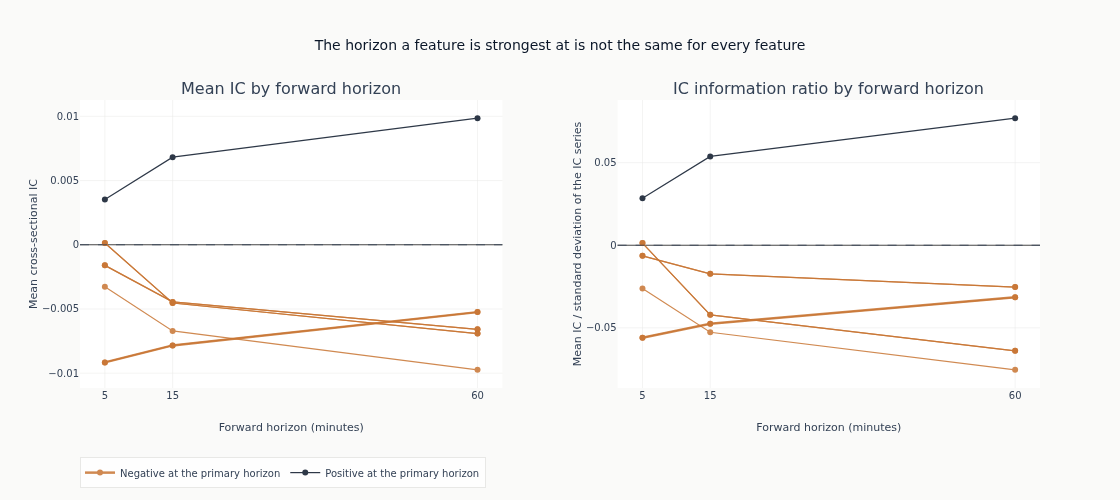

In [30]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Mean IC by forward horizon",
        "IC information ratio by forward horizon",
    ),
    horizontal_spacing=0.12,
)
shown_direction = set()
for feature in leaders:
    profile = horizon_ic.filter(pl.col("feature") == feature).sort("horizon")
    at_primary = profile.filter(pl.col("horizon") == LABEL_HORIZON)["ic_mean"]
    if not len(at_primary):
        continue
    positive = float(at_primary[0]) > 0
    group = "Positive at the primary horizon" if positive else "Negative at the primary horizon"
    style = {
        "color": COLORS["blue"] if positive else COLORS["copper"],
        "width": 2.5 if feature == leader else 1.2,
    }
    for column, column_index in (("ic_mean", 1), ("icir", 2)):
        first = column_index == 1 and group not in shown_direction
        _ = fig.add_trace(
            go.Scatter(
                x=profile["horizon"],
                y=profile[column],
                mode="lines+markers",
                line=style,
                opacity=0.85,
                name=group,
                legendgroup=group,
                showlegend=first,
                hovertext=feature,
            ),
            row=1,
            col=column_index,
        )
    shown_direction.add(group)
_ = fig.add_hline(y=0, line={"color": COLORS["neutral"], "width": 0.8, "dash": "dash"})
fig.update_layout(
    title="The horizon a feature is strongest at is not the same for every feature",
    height=500,
    width=1120,
    legend={"orientation": "h", "y": -0.24},
)
for column_index in (1, 2):
    fig.update_xaxes(
        title_text="Forward horizon (minutes)",
        tickmode="array",
        tickvals=sorted(LABEL_HORIZONS.values()),
        row=1,
        col=column_index,
    )
fig.update_yaxes(title_text="Mean cross-sectional IC", row=1, col=1)
fig.update_yaxes(title_text="Mean IC / standard deviation of the IC series", row=1, col=2)
fig.show()

## 4. Shape Diagnostics

A rank correlation says the ordering is right on average. It does not say the
relationship is usable. Sorting the names into five equal-sized bins by the feature
and taking the mean forward return in each shows the shape behind the correlation: a
profile that climbs from the lowest bin to the highest is what a strategy that goes
long the top names and short the bottom ones is relying on, while a correlation of
the same size sitting on a flat middle with two extreme bins is usually a handful of
outliers. The **monotonicity score** below is the rank correlation between the bin
index and the bin's mean return, so plus one is a profile that rises at every step
and minus one is one that falls at every step.

**The bins are cut inside each minute, and the averages are taken in that order too.**
A name's bin says where it sits against the other names quoted in the same minute,
which is the choice the strategy faces, and the mean return of a bin is taken across
those names first and then across minutes, so every minute counts once however many
names it quoted. Cutting the edges over the whole sample instead would let every other
minute's distribution help set this minute's edges, so a bin would mix where a name
sits against its peers with where the market sits against other times; averaging every
name-minute in one pass would let the busiest minutes set the shape. Both are silent
and both would leave this diagnostic answering a different question from the
correlation it sits beside, which is already a per-minute statistic averaged over
minutes.

One consequence is worth reading off the chart: a feature and its own cross-sectional
z-score twin rank the names identically inside a minute, so their correlations agree to
every digit and their profiles now agree as well.

In [31]:
N_QUANTILES = 5
top_features_for_shape = eval_summary.filter(pl.col("fdr_sig").fill_null(False))[
    "feature"
].to_list()[:15]

if not top_features_for_shape:
    top_features_for_shape = eval_summary.head(10)["feature"].to_list()

monotonicity_scores = {}
quantile_spreads = {}
for feat in top_features_for_shape:
    profile = quantile_profile(
        eval_panel,
        feat,
        label_col,
        date_col=DATE_COL,
        n_quantiles=N_QUANTILES,
        min_cross_section=MIN_PERIODS,
    )
    if profile is None:
        continue
    quantile_spreads[feat] = {"q_means": profile.means, "spread": profile.spread}
    monotonicity_scores[feat] = profile.monotonicity

n_monotone = sum(1 for s in monotonicity_scores.values() if abs(s) >= MONOTONICITY_MIN)
print(
    f"Quantile profiles: {n_monotone} of {len(monotonicity_scores)} features climb or fall"
    f" steadily enough to reach |monotonicity| >= {MONOTONICITY_MIN}"
)
for feat, score in list(monotonicity_scores.items())[:6]:
    print(f"  {feat:<26} {score:+.2f}")

Quantile profiles: 6 of 6 features climb or fall steadily enough to reach |monotonicity| >= 0.8
  r1m                        -0.90
  r1m_xs                     -0.90
  sig2_trd_ret               +1.00
  sig2_ret_trd               -1.00
  signed_vol_share_60m       -1.00
  signed_vol_share_60m_xs    -1.00


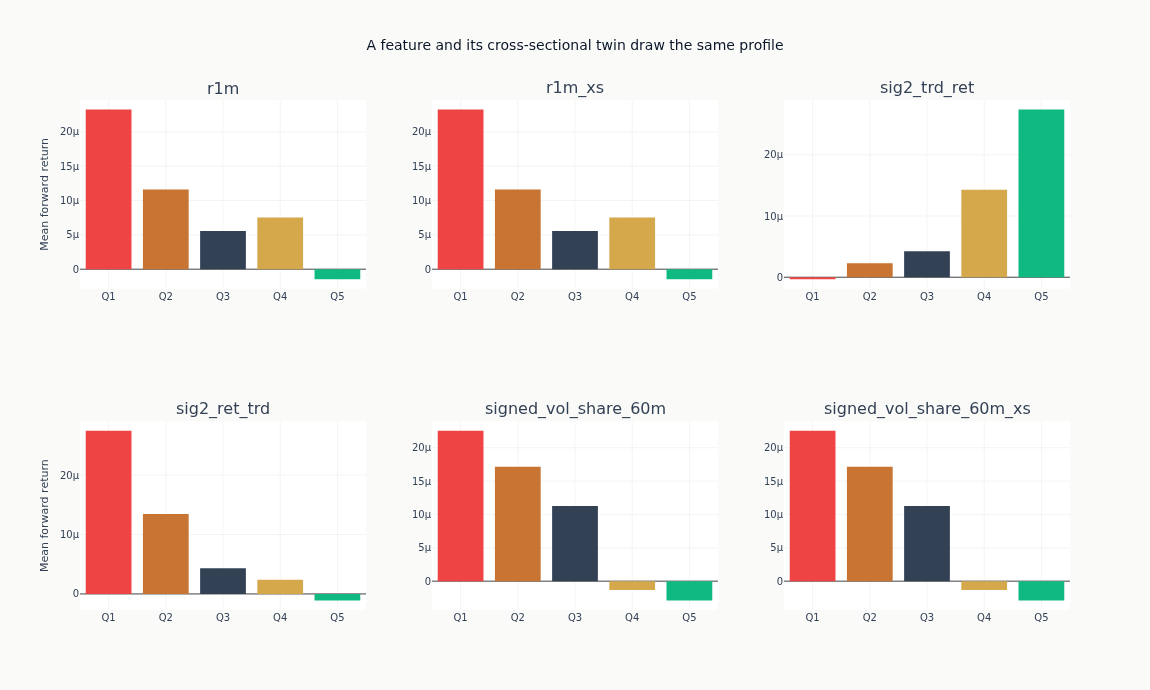

In [32]:
QUANTILE_SHADES = [
    COLORS["negative"],
    COLORS["copper"],
    COLORS["neutral"],
    COLORS["amber"],
    COLORS["positive"],
]
if quantile_spreads:
    n_show = min(6, len(quantile_spreads))
    feats_to_show = list(quantile_spreads.keys())[:n_show]
    ncols = min(3, n_show)
    nrows = (n_show + ncols - 1) // ncols
    fig = make_subplots(
        rows=nrows,
        cols=ncols,
        subplot_titles=feats_to_show,
        vertical_spacing=0.26,
    )
    for idx, feat in enumerate(feats_to_show):
        r, c = divmod(idx, ncols)
        q_means = quantile_spreads[feat]["q_means"]
        _ = fig.add_trace(
            go.Bar(
                x=[f"Q{i + 1}" for i in range(len(q_means))],
                y=q_means,
                marker_color=QUANTILE_SHADES[: len(q_means)],
                showlegend=False,
            ),
            row=r + 1,
            col=c + 1,
        )
    fig.update_layout(
        title="A feature and its cross-sectional twin draw the same profile",
        height=290 * nrows + 110,
        width=1150,
    )
    fig.update_yaxes(title_text="Mean forward return", col=1)
    fig.show()

## 5. Redundancy and Feature Families

Two candidates that rank the universe the same way are one piece of evidence entered
twice. That matters twice over: a model fitted on both splits the weight it would
have given to one, and a screen that counts them separately overstates how much
independent support a hypothesis has. This section finds the pairs and then groups
the whole candidate set into families, so the reader can see whether a family's
apparent strength rests on one measurement or on several.

Families were assigned when the candidate set was first shown, above, so this section
only has to use them.

The pairwise correlation is taken over a subsample of timestamps rather than the
whole panel. Two features that rank the universe alike do so on any large sample of
bars, so a couple of hundred timestamps spread across the period settles the
question at a fraction of the cost of a full pass.

In [33]:
sample_corr_step = max(1, n_dates // 200)
corr_dates = eval_panel[DATE_COL].unique().sort().to_list()[::sample_corr_step]
corr_data = eval_panel.filter(pl.col(DATE_COL).is_in(corr_dates)).select(evaluable_features)
corr_matrix = corr_data.to_pandas().corr(method="spearman")

# Count high-correlation pairs
high_corr_pairs = []
for i in range(len(corr_matrix)):
    for j in range(i + 1, len(corr_matrix)):
        if abs(corr_matrix.iloc[i, j]) > REDUNDANCY_CUT:
            high_corr_pairs.append(
                (corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
            )

print(f"Redundancy cut: |rank correlation| > {REDUNDANCY_CUT}")
print(f"Feature pairs above the cut: {len(high_corr_pairs)}")

Redundancy cut: |rank correlation| > 0.7
Feature pairs above the cut: 80


### Association by Family

Two views of the same grouping, because they answer different questions. The left
panel averages the absolute mean IC within each family, which is how strong the
family's typical ranked feature is. The right panel counts the family's ranked
features and marks how many of them cleared the false-discovery adjustment, which is
how broadly that strength is spread. A family carrying one strong column and eleven
weak ones and a family carrying twelve middling ones can average alike; only the
second panel separates them, and the redundancy figure below then says whether the
several are really several.

Both panels cover the features that produced an IC, not every candidate: a feature
the correctness screen removed, or one identical across the cross-section, has no
association to average or to adjust. The candidate-set table near the top of the
notebook is where the full column counts per family are.

In [34]:
family_ic = {}
fdr_sig_features = eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list()

for feat in ic_results:
    fam = families.get(feat, "other")
    family_ic.setdefault(fam, []).append(
        {
            "feature": feat,
            "ic": ic_results[feat]["mean_ic"],
            "fdr_sig": feat in fdr_sig_features,
        }
    )

family_summary = {}
for fam, feats in sorted(family_ic.items()):
    ics = [f["ic"] for f in feats if f["ic"] is not None]
    n_sig = sum(1 for f in feats if f["fdr_sig"])
    family_summary[fam] = {
        "n_features": len(feats),
        "avg_abs_ic": float(np.mean([abs(ic) for ic in ics])) if ics else 0.0,
        "avg_ic": float(np.mean(ics)) if ics else 0.0,
        "n_fdr_sig": n_sig,
    }

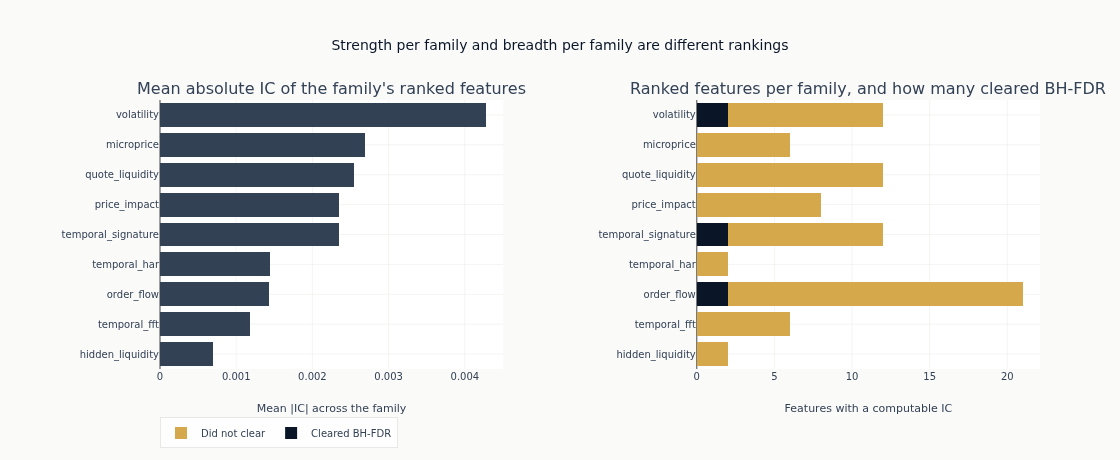

In [35]:
if family_summary:
    fam_order = sorted(family_summary, key=lambda fam: family_summary[fam]["avg_abs_ic"])
    fig = make_subplots(
        rows=1,
        cols=2,
        column_widths=[0.5, 0.5],
        subplot_titles=(
            "Mean absolute IC of the family's ranked features",
            "Ranked features per family, and how many cleared BH-FDR",
        ),
        horizontal_spacing=0.22,
    )
    _ = fig.add_trace(
        go.Bar(
            x=[family_summary[fam]["avg_abs_ic"] for fam in fam_order],
            y=fam_order,
            orientation="h",
            marker_color=COLORS["neutral"],
            showlegend=False,
        ),
        row=1,
        col=1,
    )
    _ = fig.add_trace(
        go.Bar(
            x=[family_summary[fam]["n_fdr_sig"] for fam in fam_order],
            y=fam_order,
            orientation="h",
            marker_color=COLORS["blue"],
            name="Cleared BH-FDR",
        ),
        row=1,
        col=2,
    )
    _ = fig.add_trace(
        go.Bar(
            x=[
                family_summary[fam]["n_features"] - family_summary[fam]["n_fdr_sig"]
                for fam in fam_order
            ],
            y=fam_order,
            orientation="h",
            marker_color=COLORS["amber"],
            name="Did not clear",
        ),
        row=1,
        col=2,
    )
    fig.update_layout(
        title="Strength per family and breadth per family are different rankings",
        barmode="stack",
        height=460,
        width=1120,
        margin={"l": 160},
        legend={"orientation": "h", "y": -0.18},
    )
    fig.update_xaxes(title_text="Mean |IC| across the family", row=1, col=1)
    fig.update_xaxes(title_text="Features with a computable IC", row=1, col=2)
    fig.show()

### The Strongest Redundant Pairs

Ranked pairs rather than the full matrix. At this many features an unmasked heatmap
is mostly empty space with tick labels too small to read, and the question this
section asks is about specific pairs: which two candidates are the same evidence
entered twice. Each bar names both members and the family each belongs to, so a pair
drawn from inside one family and a pair spanning two are distinguishable. The second
kind is the one that matters most, because a selection that keeps one representative
per family would not notice it.

The counts printed below the figure separate those two kinds, and separate out a
third: pairs that are a level against its own cross-sectional z-score. Those are
redundant by construction rather than by anything the data did.

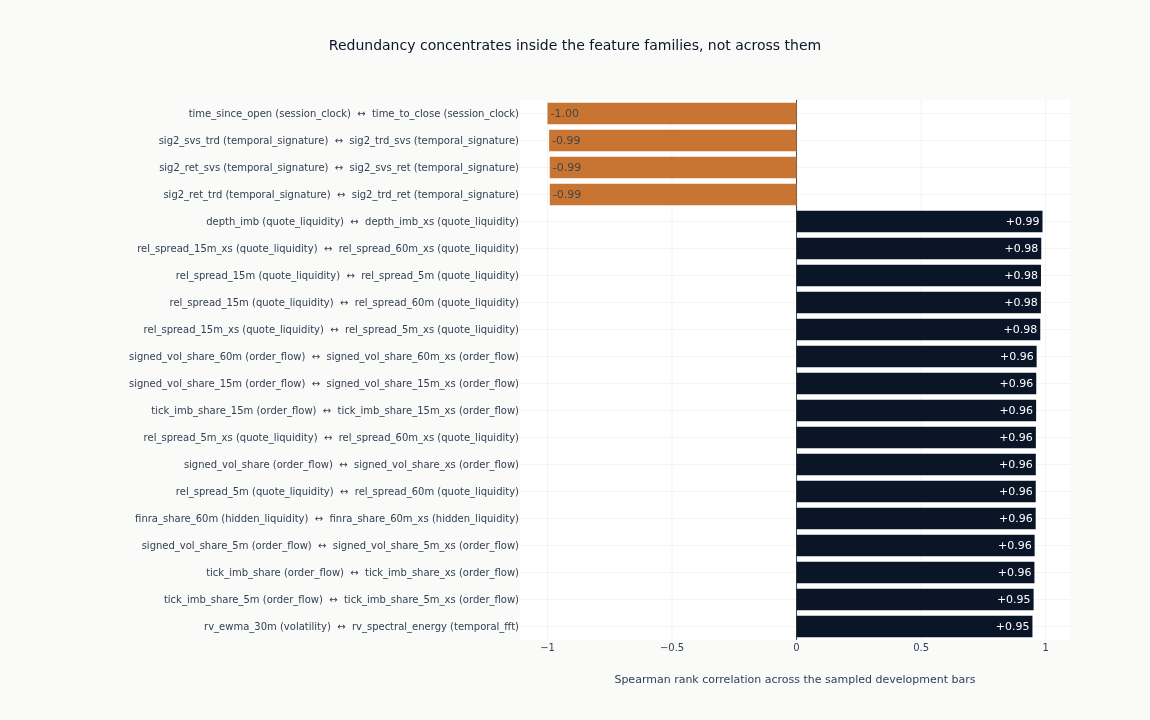

Of the 20 strongest pairs, 1 span two families
Of the 20 strongest pairs, 9 are a level against its own z-score


In [36]:
RANKED_PAIRS = 20
if high_corr_pairs:
    ranked = sorted(high_corr_pairs, key=lambda pair: abs(pair[2]), reverse=True)[:RANKED_PAIRS]
    pair_labels = [
        f"{left} ({families.get(left, 'other')})  ↔  {right} ({families.get(right, 'other')})"
        for left, right, _ in ranked
    ]
    pair_values = [float(value) for _, _, value in ranked]
    cross_family = sum(
        families.get(left, "other") != families.get(right, "other") for left, right, _ in ranked
    )
    # A level against its own cross-sectional z-score: the same measurement twice,
    # which the family declaration already says is one hypothesis on two scales.
    same_twin = sum(left == f"{right}_xs" or right == f"{left}_xs" for left, right, _ in ranked)
    fig = go.Figure(
        go.Bar(
            x=list(reversed(pair_values)),
            y=list(reversed(pair_labels)),
            orientation="h",
            marker_color=[
                COLORS["blue"] if value > 0 else COLORS["copper"] for value in reversed(pair_values)
            ],
            text=[f"{value:+.2f}" for value in reversed(pair_values)],
            textposition="inside",
        )
    )
    fig.update_layout(
        title="Redundancy concentrates inside the feature families, not across them",
        xaxis_title="Spearman rank correlation across the sampled development bars",
        height=720,
        width=1150,
        margin={"l": 520},
        showlegend=False,
    )
    fig.show()
    print(f"Of the {len(ranked)} strongest pairs, {cross_family} span two families")
    print(f"Of the {len(ranked)} strongest pairs, {same_twin} are a level against its own z-score")

## 6. Triage and Handoff

The book's Table 7.2 rule, with every bound taken from the configuration cell.

| Decision | Criteria |
|----------|----------|
| **PROCEED** | cleared BH-FDR, **or** both folds agreeing to at least `SIGN_CONSISTENCY_MIN` and an absolute mean IC of at least `IC_THRESHOLD` |
| **STOP** | failed the correctness screen: coverage below `COVERAGE_MIN`, or repetition above `STALENESS_MAX` |
| **REVISE** | everything else - carried forward, to be judged inside a fit that sees every feature at once |

The promotion rule is a **disjunction**: a feature reaches PROCEED on either arm, so
the promoted count can exceed the count that cleared the adjustment. Which arm fired
is recorded in the ledger's `note` column, so a later reader can audit the decision
instead of inferring it.

The two arms are not the same kind of evidence, and §7.4 asks that the difference be
stated rather than left to be discovered. The first is a **confirmation** arm: it
rejects a null hypothesis at a level corrected for how many features were tested.
The second is an **exploration** arm: it asks whether the association is large enough
to be worth carrying and points the same way in both folds, which is a judgment
about effect size rather than a test. A feature promoted through the second arm has
not been confirmed by anything, and the models downstream are where it earns its
place or loses it.

`monotonicity` is written to the ledger as evidence and is **not** read by the rule
above. A reader comparing the promoted count to the count that cleared BH-FDR should
not expect the shape diagnostic to explain the difference.

In [37]:
triage = {}
for feat in all_feature_cols:
    if not correctness[feat]:
        triage[feat] = ("STOP", failure_reason[feat])
        continue

    if feat not in ic_results:
        triage[feat] = ("REVISE", "insufficient_data")
        continue

    is_fdr_sig = feat in fdr_sig_features
    sign_con = fold_stats.get(feat, {}).get("sign_consistency", 0)
    abs_ic = abs(ic_results[feat]["mean_ic"])

    if is_fdr_sig:
        triage[feat] = ("PROCEED", "fdr_significant")
    elif sign_con >= SIGN_CONSISTENCY_MIN and abs_ic >= IC_THRESHOLD:
        triage[feat] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feat] = ("REVISE", "not_significant_standalone")

The ledger is one row per candidate carrying the decision and every quantity that
produced it, so the decision can be re-derived from the file rather than taken on
trust. It is written beside a long-format copy of the IC series itself, which keeps
the per-timestamp evidence behind every mean IC on this page.

In [38]:
ledger_rows = []
for feat in all_feature_cols:
    decision, note = triage[feat]
    row = {
        "feature": feat,
        "family": families.get(feat, "other"),
        "source": "temporal" if feat in temporal_cols else "financial",
        "ic_mean": ic_results.get(feat, {}).get("mean_ic"),
        "hac_t": ic_results.get(feat, {}).get("t_stat"),
        "hac_p": ic_results.get(feat, {}).get("p_value"),
        "fdr_p": None,
        "fdr_sig": False,
        "sign_consistency": fold_stats.get(feat, {}).get("sign_consistency"),
        "worst_fold_ic": fold_stats.get(feat, {}).get("worst_fold_ic"),
        "monotonicity": monotonicity_scores.get(feat),
        "coverage": coverage[feat],
        "staleness": staleness[feat],
        "decision": decision,
        "note": note,
    }
    match = eval_summary.filter(pl.col("feature") == feat)
    if len(match) > 0:
        row["fdr_p"] = float(match["fdr_p"][0])
        row["fdr_sig"] = bool(match["fdr_sig"][0])
    ledger_rows.append(row)

triage_ledger = pl.DataFrame(ledger_rows)
triage_ledger.write_parquet(EVAL_WRITE_DIR / "triage_ledger.parquet")

ic_ts_frames = [
    ts.with_columns(pl.lit(feat).alias("feature")) for feat, ts in ic_timeseries.items()
]
if ic_ts_frames:
    pl.concat(ic_ts_frames).write_parquet(EVAL_WRITE_DIR / "ic_timeseries.parquet")

print(f"Wrote triage_ledger.parquet ({len(triage_ledger)} rows) and ic_timeseries.parquet")

Wrote triage_ledger.parquet (88 rows) and ic_timeseries.parquet


### The Funnel

What was searched, what survived each stage, and what each arm of the promotion rule
contributed. Drawn rather than printed, because the width of the drop between
consecutive bars is what a reader is meant to weigh, and the two arms are separated
so a rule that reads as a disjunction can be seen to behave like one, or not to.

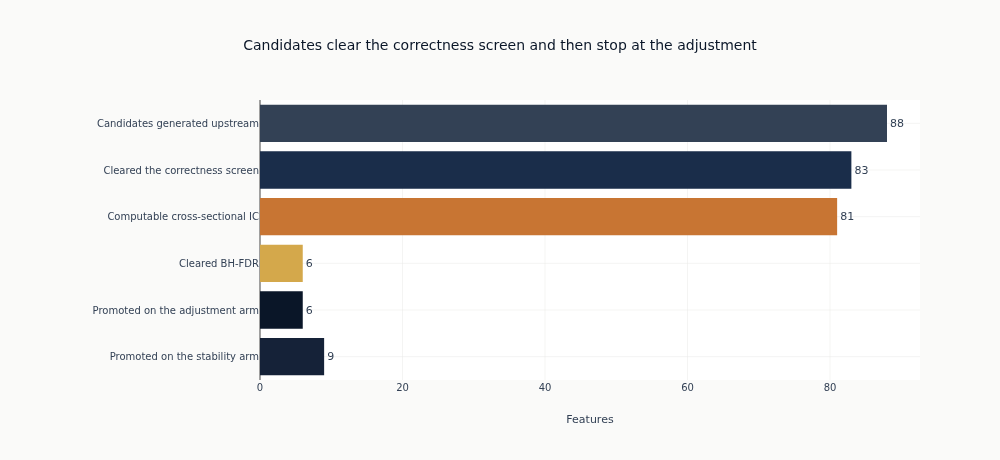

In [39]:
arm_counts = {
    note: len([f for f, (d, n) in triage.items() if d == "PROCEED" and n == note])
    for note in ("fdr_significant", "stable_and_above_threshold")
}
funnel_stages = [
    ("Candidates generated upstream", len(all_feature_cols), COLORS["neutral"]),
    ("Cleared the correctness screen", n_pass, COLORS["slate"]),
    ("Computable cross-sectional IC", n_searched, COLORS["copper"]),
    ("Cleared BH-FDR", n_significant_fdr, COLORS["amber"]),
    ("Promoted on the adjustment arm", arm_counts["fdr_significant"], COLORS["blue"]),
    (
        "Promoted on the stability arm",
        arm_counts["stable_and_above_threshold"],
        COLORS["blue_light"],
    ),
]
fig = go.Figure(
    go.Bar(
        x=[count for _, count, _ in funnel_stages],
        y=[stage for stage, _, _ in funnel_stages],
        orientation="h",
        marker_color=[color for _, _, color in funnel_stages],
        text=[str(count) for _, count, _ in funnel_stages],
        textposition="outside",
    )
)
fig.update_layout(
    title="Candidates clear the correctness screen and then stop at the adjustment",
    xaxis_title="Features",
    height=460,
    width=1000,
    margin={"l": 260, "r": 80},
    showlegend=False,
)
fig.update_yaxes(autorange="reversed")
fig.show()

In [40]:
decisions = dict(triage_ledger.group_by("decision").len().iter_rows())
# The exploration arm only ever sees what the confirmation arm did not take: the decision
# above is an if/elif, so a feature satisfying both is recorded against the confirmation
# arm. Counting the bar over every feature would therefore compare the arm's promotions
# against a group it never chose from, and attribute to fold agreement a difference that
# is partly the other arm having gone first.
eligible = [f for f in ic_results if f not in fdr_sig_features]
above_threshold = sum(1 for f in eligible if abs(ic_results[f]["mean_ic"]) >= IC_THRESHOLD)
print(
    f"{decisions.get('PROCEED', 0)} features are recorded PROCEED,"
    f" {decisions.get('REVISE', 0)} REVISE and {decisions.get('STOP', 0)} STOP."
)
print(
    f"Of the promotions, {arm_counts['fdr_significant']} came through the confirmation arm"
    f" and {arm_counts['stable_and_above_threshold']} through the exploration arm."
)
print(
    f"The exploration arm chooses among the {len(eligible)} features the confirmation arm"
    f" did not take. Its effect-size bar of {IC_THRESHOLD} is cleared by {above_threshold}"
    " of them, so what separates its promotions from the rest of that group is fold"
    " agreement rather than the bar."
)

15 features are recorded PROCEED, 68 REVISE and 5 STOP.
Of the promotions, 6 came through the confirmation arm and 9 through the exploration arm.
The exploration arm chooses among the 75 features the confirmation arm did not take. Its effect-size bar of 0.003 is cleared by 18 of them, so what separates its promotions from the rest of that group is fold agreement rather than the bar.


## Key Takeaways

### What the screen does

1. **Remove the reserved period before anything is measured**, and remove it on the
   time a label settles rather than the time a bar is observed. The coverage screen,
   the IC, the quantile profile and the redundancy correlation then all describe the
   development period alone. A sentence saying so is not a substitute; a filter and
   an assertion are.
2. **One rank correlation across the assets at each timestamp**, sampled at one
   observation per label horizon so neighbouring observations do not predict the same
   stretch of returns, then averaged with a Newey-West correction over one session
   of lags.
3. **Say what was searched before quoting a p-value.** An adjustment is only
   interpretable against the set of tests it came out of, and that set is fixed by
   the rules that generated the features, not by what this screen found.
4. **Ask whether a feature is present and moving** before asking what it predicts.

### Triage logic

- **PROCEED**: evidence of predictive content on either arm, confirmation or
  exploration. Carried into model training.
- **REVISE**: too marginal on its own to promote, and still worth carrying, because
  a fit that sees every feature at once can find use for a feature a one-at-a-time
  screen cannot.
- **STOP**: failed a basic quality check.

### Known limitations of this screen

- Fold agreement counts folds with a positive IC rather than folds sharing the
  feature's own direction, so a feature that is consistently negative cannot clear
  the exploration arm however stable it is.
- The repetition screen counts repeats and cannot ask why a value repeated, so a
  session flag or a discrete index fails it for the same reason a frozen quote does.
- Quantile bins are assigned over the pooled sample rather than within each
  timestamp, so the shape diagnostic and the IC answer slightly different questions.
- The minimum cross-section is applied to the number of rows at a timestamp, not to
  the number of non-null feature-label pairs, so a sparse feature can contribute a
  thin cross-section at full weight.
- Screening one feature at a time is necessary and not sufficient. Nothing here
  claims tradability; the multivariate fit and the backtest decide that.

**Next**: `20_strategy_synthesis/02_feature_evaluation.py` reads
`evaluation/triage_ledger.parquet` from every case study and puts the nine screens
side by side. `evaluation/ic_timeseries.parquet` is read here, by the
IC-through-time figure above.